In [1]:
import pandas as pd

# load processed data
Xf = pd.read_pickle("data/processed/Xf.pkl")
meta = pd.read_pickle("data/processed/meta.pkl")
clusters = pd.read_pickle("data/processed/clusters.pkl")

clusters.value_counts()


cluster
1    72
2    66
0    62
Name: count, dtype: int64

In [2]:
import pandas as pd
import xgboost as xgb

# 1) SHAP important genes
imp = pd.read_csv("data/processed/shap_importance.csv")
top_genes = imp["gene"].head(50).tolist()

# 2) model if you wnat
model = xgb.XGBClassifier()
model.load_model("data/models/xgb_model.json")

top_genes[:10], imp.head()


(['G6993',
  'G4480',
  'G2951',
  'G400',
  'G3611',
  'G3560',
  'G1446',
  'G3939',
  'G4457',
  'G1561'],
     gene  mean_abs_shap
 0  G6993       0.351298
 1  G4480       0.331959
 2  G2951       0.289228
 3   G400       0.230345
 4  G3611       0.204908)

In [3]:
# Define comparison groups

groups = clusters
groups.value_counts()

cluster
1    72
2    66
0    62
Name: count, dtype: int64

In [4]:
# Differential expression (simple t-test)

import pandas as pd
from scipy.stats import ttest_ind

group0 = Xf[groups == 0]
group1 = Xf[groups == 1]

stat, pval = ttest_ind(group0, group1, axis=0, equal_var=False)

deg = pd.DataFrame({
    "gene": Xf.columns,
    "pvalue": pval,
    "logFC": group1.mean() - group0.mean()
}).sort_values("pvalue")

deg.head()

,gene,pvalue,logFC
G6562,G6562,0.000009,0.713502
G954,G954,0.000056,-0.720038
G7023,G7023,0.000081,0.616359
G1304,G1304,0.000228,0.619090
G7678,G7678,0.000298,-0.591575


In [5]:
# Select top candidate genes

top_genes = deg.query("pvalue < 0.01").head(50)
top_genes

,gene,pvalue,logFC
G6562,G6562,0.000009,0.713502
G954,G954,0.000056,-0.720038
G7023,G7023,0.000081,0.616359
G1304,G1304,0.000228,0.619090
G7678,G7678,0.000298,-0.591575
G3544,G3544,0.000380,0.570905
G235,G235,0.000489,-0.603092
G2474,G2474,0.000510,-0.614412
G490,G490,0.000578,-0.617642
G3871,G3871,0.000732,0.601284


<Axes: ylabel='gene'>

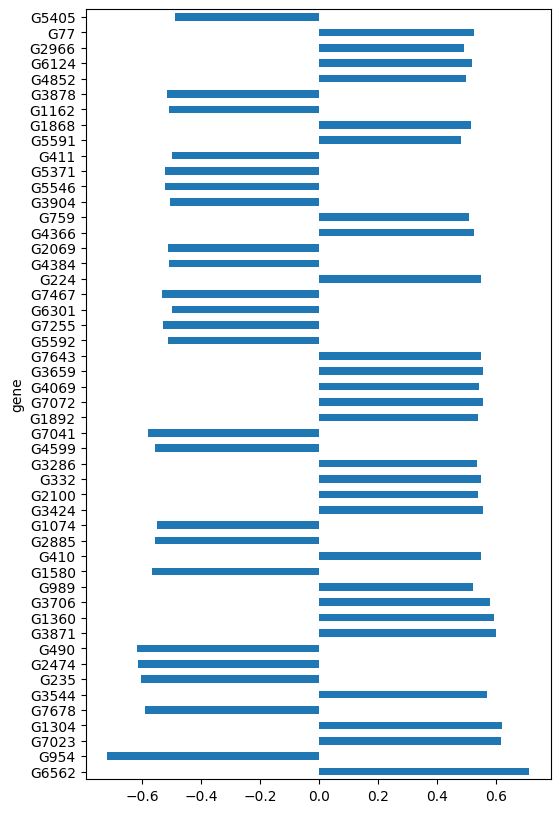

In [6]:
# (Optional) quick sanity plot

top_genes.set_index("gene")["logFC"].plot.barh(figsize=(6, 10))

In [7]:
import os
os.getcwd()


'/Users/dohoonkim/Downloads/FROG-MOMI/notebooks'

In [8]:
imp = pd.read_csv("data/processed/shap_importance.csv")
shap_top = imp["gene"].head(50).tolist()


In [9]:
deg_top = deg.query("pvalue < 0.01").head(200)["gene"].tolist()


In [10]:
cand = sorted(set(shap_top).intersection(set(deg_top)))
len(cand), cand[:20]


(0, [])

In [11]:
os.makedirs("data/processed", exist_ok=True)

pd.Series(cand, name="candidate_gene").to_csv(
    "data/processed/candidate_genes.csv", index=False
)

deg.to_csv("data/processed/deg_cluster0_vs_1.csv", index=False)


In [12]:
print("len(shap_top):", len(shap_top), " example:", shap_top[:10])
print("len(deg_top):", len(deg_top), " example:", deg_top[:10])

shap_set = set(shap_top)
deg_set = set(deg_top)

print("overlap:", len(shap_set & deg_set))
print("shap not in deg (sample):", list(shap_set - deg_set)[:10])
print("deg not in shap (sample):", list(deg_set - shap_set)[:10])


len(shap_top): 50  example: ['G6993', 'G4480', 'G2951', 'G400', 'G3611', 'G3560', 'G1446', 'G3939', 'G4457', 'G1561']
len(deg_top): 110  example: ['G6562', 'G954', 'G7023', 'G1304', 'G7678', 'G3544', 'G235', 'G2474', 'G490', 'G3871']
overlap: 0
shap not in deg (sample): ['G400', 'G2951', 'G2840', 'G1876', 'G6676', 'G6471', 'G1825', 'G3472', 'G3877', 'G4480']
deg not in shap (sample): ['G235', 'G490', 'G2474', 'G4033', 'G7571', 'G1976', 'G7332', 'G1580', 'G1892', 'G759']


In [13]:
from scipy.stats import ttest_ind
import pandas as pd

y = meta["label"]  # 0/1
g0 = Xf[y == 0]    # Alive
g1 = Xf[y == 1]    # Dead

stat, pval = ttest_ind(g0, g1, axis=0, equal_var=False)

deg_label = pd.DataFrame({
    "gene": Xf.columns,
    "pvalue": pval,
    "logFC": g1.mean() - g0.mean()
}).sort_values("pvalue")

deg_top_label = deg_label.query("pvalue < 0.01").head(200)["gene"].astype(str).tolist()

cand = sorted(set(shap_top).intersection(set(deg_top_label)))
len(cand), cand[:20]


(24,
 ['G1018',
  'G1124',
  'G1825',
  'G1876',
  'G2048',
  'G2639',
  'G2951',
  'G3819',
  'G3877',
  'G3939',
  'G400',
  'G4457',
  'G4480',
  'G4660',
  'G5208',
  'G5925',
  'G6471',
  'G6676',
  'G6993',
  'G743'])

In [14]:
cand_union = sorted(set(shap_top).union(set(deg_top_label)))
len(cand_union)


113

In [15]:
import os
import pandas as pd

os.makedirs("data/processed", exist_ok=True)

# 교집합 (가장 강한 후보)
pd.Series(cand, name="candidate_gene").to_csv(
    "data/processed/candidate_genes_intersection.csv", index=False
)

# 합집합 (넓은 후보)
pd.Series(cand_union, name="candidate_gene").to_csv(
    "data/processed/candidate_genes_union.csv", index=False
)

# label 기반 DEG 전체도 저장 (나중에 필터링용)
deg_label.to_csv(
    "data/processed/deg_label_based.csv", index=False
)
